# 05 — Model selection, tuning, and registration

Every number this notebook reports has to survive the question *"how do you know?"*.
The protocol below is built so that it can.

## Selection protocol

```
Gold feature store
        |
        +-- CV window (<= 2021) --------------------+     OUTER: temporal holdout.
        |        |                                  |     Nothing downstream of this
        |        +-- fold 0 (contiguous quarters)   |     block sees 2022 or 2023.
        |        +-- fold 1                          |
        |        +-- ...    INNER: blocked K-fold    |
        |        +-- fold 4 via CrossValidator(foldCol)
        |                                            |
        +-- THRESHOLD window (2022) ----------------+ <- never enters CV;
        |                                                 picks the decision cut
        |
        +-- TEST window (2023) ---------------------+ <- evaluated EXACTLY once
```

**Why three windows and not two.** `CrossValidator.fit()` refits `bestModel` on its
*entire* input. So every fold of the CV window — including whichever fold you might be
tempted to call "validation" afterwards — has been trained on by the time a champion
exists. Selecting the decision threshold on such a fold reports an optimistically biased
cut. 2022 is therefore carved out *before* cross-validation and never enters it.

**Stage 0 — baselines.** Majority class, and a logistic regression on `dep_delay` alone.
Nothing that follows counts unless it beats these. Both are scored on the 2022 validation
window, not on test — the test year stays sealed until Stage 3.

**Stage 1 — how many features?** `UnivariateFeatureSelector` swept over K, scored by
blocked CV. The selector is a *Pipeline stage*, so it is refitted inside every fold —
selecting on the full data first would let it see the validation rows.

**Stage 2 — which family, which hyperparameters?** Four model families compared under
identical CV, then Hyperopt TPE explores the two survivors on a sample, then
`CrossValidator` re-scores the top configurations on the full CV window.

**Stage 3 — final fit, one test evaluation.** Threshold selected on 2022, applied
unchanged to 2023. Calibration and error analysis on the test predictions.

Stages 2b–3 run for **both** feature views — pre-departure and in-flight — through
`run_variant()`. The AUC gap between them is the measurable price of predicting before
pushback.

Runtime warning: this is the longest notebook in the project. Set `fast_mode=true`
for iteration — it cuts folds and evaluations without changing the structure.


In [0]:
%pip install hyperopt -q
dbutils.library.restartPython()


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import mlflow

# `mlflow.spark` and `mlflow.pyspark.ml` are submodules — `import mlflow` alone does
# not reliably bind them, and `mlflow.pyspark.ml.autolog(...)` below then raises
# AttributeError. Import them explicitly.
import mlflow.spark
import mlflow.pyspark.ml
import numpy as np
import pandas as pd
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import (
    DecisionTreeClassifier, GBTClassifier, LogisticRegression, RandomForestClassifier,
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import (
    OneHotEncoderModel, UnivariateFeatureSelector, VectorAssembler, VectorSlicer,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import functions as F
from pyspark.sql.functions import col

from src import config, evaluation as ev, plotting as P

dbutils.widgets.dropdown("fast_mode", "false", ["true", "false"])
FAST = dbutils.widgets.get("fast_mode") == "true"

CV_FOLDS = 2 if FAST else config.CV_FOLDS
SEARCH_FOLDS = 2 if FAST else config.SEARCH_CV_FOLDS
MAX_EVALS = 4 if FAST else config.HYPEROPT_MAX_EVALS
SAMPLE_FRACTION = 0.05 if FAST else config.SEARCH_SAMPLE_FRACTION

mlflow.set_registry_uri(config.MLFLOW_REGISTRY_URI)
mlflow.set_experiment(config.MLFLOW_EXPERIMENT)
mlflow.pyspark.ml.autolog(disable=True)   # explicit logging only; autolog buries the structure

evaluator = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="probability", metricName=config.TUNING_METRIC
)
print(f"fast_mode={FAST}  folds={CV_FOLDS}  search_folds={SEARCH_FOLDS}  evals={MAX_EVALS}")
print(f"MLflow {mlflow.__version__}")


fast_mode=True  folds=2  search_folds=2  evals=4
MLflow 3.8.1


## Split protocol

The outer split is temporal because `02_eda` §3 showed delay compounding across the
operating day — a random split would place a delay and the flight it caused on opposite
sides of the boundary.

The inner folds inherit the same reasoning. Spark's `CrossValidator` partitions randomly by
default, which reintroduces exactly the leak the outer split removed. `foldCol` (Spark 3.1+)
lets us supply the partition instead: contiguous quarters, so each fold validates on a
time block the model did not train on.

**Two fold columns, not one.** The search stages run 3-fold CV on a sample while the
confirming stage runs 5-fold on everything. `CrossValidator` requires the fold column's
values to be exactly `[0, numFolds)`, so a single column cut at `CV_FOLDS` breaks every
stage that asks for `SEARCH_FOLDS`. Each granularity gets its own column, and both are
asserted below.

**What this controls for and what it does not.** Blocked CV removes within-day and
within-quarter leakage. It is not strictly forward-chaining — fold 0 trains on quarters that
come *after* it in time. Rolling-origin CV would be stricter, at k× the cost for a dataset
with no strong long-run trend once 2020 is excluded. Blocked was the trade taken; the
alternative is named so a reader can disagree with it.


In [0]:
gold = spark.table(config.GOLD)

cv_window = gold.filter(col("flight_year") <= config.TRAIN_END_YEAR)
val_window = gold.filter(col("flight_year") == config.THRESHOLD_YEAR)
test = gold.filter(col("flight_year") == config.TEST_YEAR)


def add_fold_column(df, n_folds, out_col):
    """Assign contiguous year-quarter blocks to fold indices [0, n_folds).

    Periods are ordered by calendar time and cut into `n_folds` chunks, so every
    fold validates on a block of time rather than a random sample of rows.
    """
    periods = [
        r["period"] for r in df
        .select(F.concat_ws("-Q", col("flight_year"), col("quarter")).alias("period"))
        .distinct().orderBy("period").collect()
    ]
    if len(periods) < n_folds:
        raise ValueError(
            f"{len(periods)} distinct periods cannot fill {n_folds} folds. "
            f"Lower CV_FOLDS/SEARCH_CV_FOLDS or widen the CV window."
        )
    mapping = {p: min(i * n_folds // len(periods), n_folds - 1) for i, p in enumerate(periods)}
    fold_df = spark.createDataFrame(
        [(p, int(f)) for p, f in mapping.items()], f"period string, {out_col} int"
    )
    out = (
        df.withColumn("period", F.concat_ws("-Q", col("flight_year"), col("quarter")))
        .join(F.broadcast(fold_df), on="period", how="left")
        .drop("period")
    )
    return out, mapping, periods


cv_window, fold_map, periods = add_fold_column(cv_window, CV_FOLDS, "fold")
cv_window, search_map, _ = add_fold_column(cv_window, SEARCH_FOLDS, "search_fold")

print(f"{'period':<10}{'fold':>6}{'search_fold':>13}")
for p in periods:
    print(f"{p:<10}{fold_map[p]:>6}{search_map[p]:>13}")

# CrossValidator requires fold values to be exactly [0, numFolds). Assert it here
# rather than discovering it several minutes into Stage 1.
for col_name, n in (("fold", CV_FOLDS), ("search_fold", SEARCH_FOLDS)):
    observed = sorted(r[0] for r in cv_window.select(col_name).distinct().collect())
    assert observed == list(range(n)), (
        f"{col_name} has values {observed}, but numFolds={n} requires {list(range(n))}"
    )
print(f"\nFold columns validated: fold=[0,{CV_FOLDS}) search_fold=[0,{SEARCH_FOLDS})")

cv_n, val_n, test_n = cv_window.count(), val_window.count(), test.count()
cv_rate = cv_window.select(F.avg("label")).first()[0]
val_rate = val_window.select(F.avg("label")).first()[0]
test_rate = test.select(F.avg("label")).first()[0]
print(f"\nCV        (<= {config.TRAIN_END_YEAR}): {cv_n:,} rows, {cv_rate:.2%} delayed")
print(f"Threshold ({config.THRESHOLD_YEAR})     : {val_n:,} rows, {val_rate:.2%} delayed")
print(f"Test      ({config.TEST_YEAR})     : {test_n:,} rows, {test_rate:.2%} delayed")
print(f"Base-rate drift CV -> test: {test_rate - cv_rate:+.2%}")


period      fold  search_fold
2019-Q1        0            0
2019-Q2        0            0
2019-Q3        0            0
2019-Q4        0            0
2021-Q1        1            1
2021-Q2        1            1
2021-Q3        1            1
2021-Q4        1            1

Fold columns validated: fold=[0,2) search_fold=[0,2)

CV        (<= 2021): 1,341,805 rows, 18.23% delayed
Threshold (2022)     : 667,761 rows, 21.04% delayed
Test      (2023)     : 454,413 rows, 23.03% delayed
Base-rate drift CV -> test: +4.80%


The base-rate drift line matters: if the delayed share moved materially between the CV
window and the test year, some of the test-set degradation is distribution shift rather than
overfitting, and the write-up should say so rather than blaming the model.

## Feature views

`dep_delay` is removed for the pre-departure variant. Its index is read out of the feature
vector's own metadata and asserted, not hardcoded — the original project's failure mode was
a magic index that silently drifted when column order changed.

**Metadata is not guaranteed to survive.** `04_gold` builds `features` with a
`StandardScaler`, which does not propagate its input's attribute names, and the vector then
round-trips through a Delta write. When `ml_attr` comes back empty the names are rebuilt
from the fitted feature pipeline that `04_gold` saved to the artifact volume — the same
source of truth, read a different way. If both fail the cell raises rather than falling back
to a magic index, because a wrong index here is silent target leakage.


In [0]:
def resolve_feature_names(df):
    """Map feature name -> vector index. Metadata first, saved pipeline second."""
    attrs = df.schema["features"].metadata.get("ml_attr", {}).get("attrs")
    if attrs:
        idx = {a["name"]: a["idx"] for group in attrs.values() for a in group}
        if idx:
            return idx, "vector metadata"

    # Fallback: rebuild from the pipeline 04_gold fitted and saved.
    path = f"{config.ARTIFACT_VOLUME}/feature_pipeline"
    model = PipelineModel.load(path)
    assembler = next(s for s in model.stages if isinstance(s, VectorAssembler))
    encoders = {s.getOutputCol(): s for s in model.stages if isinstance(s, OneHotEncoderModel)}

    idx, cursor = {}, 0
    for name in assembler.getInputCols():
        if name in encoders:
            # OneHotEncoder emits one slot per category (dropLast is respected by
            # categorySizes minus one when the encoder was fitted with it).
            enc = encoders[name]
            try:
                out_cols = enc.getOutputCols()
            except KeyError:
                out_cols = [enc.getOutputCol()]
            size = enc.categorySizes[out_cols.index(name)]
            width = size - 1 if enc.getDropLast() else size
            for j in range(width):
                idx[f"{name}[{j}]"] = cursor
                cursor += 1
        else:
            idx[name] = cursor
            cursor += 1
    return idx, f"saved pipeline at {path}"


index_by_name, source = resolve_feature_names(gold)
n_features = len(index_by_name)

if "dep_delay" not in index_by_name:
    raise KeyError(
        "dep_delay not found in the feature vector. Resolved names came from "
        f"{source}. Check 04_gold's numerical_cols. Refusing to guess an index — "
        "a wrong one silently leaks the target into the pre-departure model."
    )

dep_delay_idx = index_by_name["dep_delay"]
pre_indices = [i for i in range(n_features) if i != dep_delay_idx]

assert dep_delay_idx not in pre_indices, "dep_delay leaked into the pre-departure view"
assert len(pre_indices) == n_features - 1
print(f"Feature vector width: {n_features}")
print(f"Names resolved from: {source}")
print(f"dep_delay resolved to index {dep_delay_idx} (not hardcoded)")


def make_view(df, indices, keep=()):
    """Slice the assembled vector down to `indices`, keeping label and any extra cols."""
    if len(indices) == n_features:
        return df.select("features", "label", *keep)
    sliced = VectorSlicer(inputCol="features", outputCol="sliced", indices=indices).transform(df)
    return sliced.select(col("sliced").alias("features"), "label", *keep)


FOLD_COLS = ("fold", "search_fold")
all_indices = list(range(n_features))

train_pre = make_view(cv_window, pre_indices, keep=FOLD_COLS)
train_in = make_view(cv_window, all_indices, keep=FOLD_COLS)
val_pre = make_view(val_window, pre_indices)
val_in = make_view(val_window, all_indices)
test_pre = make_view(test, pre_indices)
test_in = make_view(test, all_indices)

search_pre = train_pre.sample(SAMPLE_FRACTION, seed=config.RANDOM_SEED)
search_in = train_in.sample(SAMPLE_FRACTION, seed=config.RANDOM_SEED)
print(f"Search sample: {search_pre.count():,} rows ({SAMPLE_FRACTION:.0%} of CV window)")


Feature vector width: 814
Names resolved from: saved pipeline at /Volumes/workspace/flights/artifacts/feature_pipeline
dep_delay resolved to index 11 (not hardcoded)
Search sample: 66,809 rows (5% of CV window)


---

## Stage 0 — Baselines

`02_eda` §2 established that a classifier predicting "on time" for every flight already scores
in the eighties on accuracy. Two baselines are fitted here so every later number has a floor
to clear:

- **Majority class** — the do-nothing model. Zero recall by construction.
- **`dep_delay` alone** — logistic regression on the single strongest feature. If the full
  in-flight model cannot beat one feature, the other 200 are not paying rent.

Both are trained on the CV window and scored on the **2022 validation window**. Scoring them
on 2023 would spend the test year in Stage 0, which is exactly what the protocol above
promises not to do.


In [ ]:
baselines = []

# Majority class: predict P(delayed)=0 for everything, scored on validation.
majority = ev.confusion_at(
    val_window.withColumn(ev.POSITIVE_PROBABILITY, F.lit(0.0)), [0.5]
)[0]
baselines.append({"model": "majority class", "roc_auc": 0.5,
                  "f1": majority["f1"], "accuracy": majority["accuracy"]})

# dep_delay alone: fit on the CV window, score on validation.
dep_train = VectorAssembler(inputCols=["dep_delay"], outputCol="features").transform(
    cv_window.select("dep_delay", "label")
)
dep_val = VectorAssembler(inputCols=["dep_delay"], outputCol="features").transform(
    val_window.select("dep_delay", "label")
)
lr_dep = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20).fit(dep_train)
report = ev.full_report(lr_dep.transform(dep_val), 0.5, beta=config.REPORTING_BETA)
baselines.append({"model": "logistic on dep_delay only", "roc_auc": report["roc_auc"],
                  "f1": report["f1"], "accuracy": report["accuracy"]})

baseline_df = pd.DataFrame(baselines)
display(baseline_df)

# Two floors, not one. The pre-departure model cannot see dep_delay, so holding it
# to a dep_delay-derived floor compares it against information it is defined not to
# have. Each variant is scored against the strongest baseline available to it.
FLOOR_PRE = 0.5                                # majority class: no ranking ability
FLOOR_PRE_F1 = float(baselines[0]["f1"])
FLOOR_IN = float(baselines[1]["roc_auc"])      # one feature, and a very strong one
FLOOR_IN_F1 = float(baselines[1]["f1"])

print(f"\nFloors to beat (measured on {config.THRESHOLD_YEAR}):")
print(f"  pre-departure  ROC-AUC {FLOOR_PRE:.4f}  F1 {FLOOR_PRE_F1:.4f}   (majority class)")
print(f"  in-flight      ROC-AUC {FLOOR_IN:.4f}  F1 {FLOOR_IN_F1:.4f}   (dep_delay alone)")
print("\nThat in-flight floor is the number to keep an eye on. A single feature")
print("already ranks this well, so the in-flight model has very little room to")
print("prove itself — see the variant comparison at the end.")


---

## Stage 1 — How many features?

`TOP_K_FEATURES` was a magic 40 in the original project. Here it is chosen by sweeping K and
reading the curve.

**Method.** `UnivariateFeatureSelector` with `featureType="continuous"`, `labelType="categorical"`
performs an ANOVA F-test per feature and keeps the top K. It sits as stage 0 of a `Pipeline`
handed to `CrossValidator`, so it is refitted on each fold's training portion only.

**The caveat, stated up front.** The vector mixes scaled numerics with binary one-hot columns.
ANOVA treats all of them as continuous, which is a standard approximation but not free: the
F-statistic for a sparse binary column is not directly comparable to one for a dense scaled
numeric. A stricter design would select within blocks, chi-squared for the binaries and ANOVA
for the numerics. K=0 (keep everything) is included as the control so the sweep can show
whether selection helps at all.

**Univariate filters also miss interactions** — a feature useless alone but valuable in
combination is discarded. That is why the winner is cross-checked against the tree ensemble's
own `featureImportances` later, which is an embedded method and does see interactions.


In [0]:
import os
os.environ["SPARKML_TEMP_DFS_PATH"] = f"{config.ARTIFACT_VOLUME}/sparkml_temp"

def cv_score(estimator, data, folds, fold_col, param_grid=None):
    """Blocked K-fold CV score. Returns (model, mean, std) of the tuning metric.

    `fold_col` must contain exactly the values [0, folds) — the search stages use
    `search_fold`, the confirming stage uses `fold`.
    """
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid or ParamGridBuilder().build(),
        evaluator=evaluator,
        numFolds=folds,
        foldCol=fold_col,
        parallelism=1,          # serverless session memory cap: fit one model at a time
        collectSubModels=False,
        seed=config.RANDOM_SEED,
    )
    model = cv.fit(data)
    best = int(np.argmax(model.avgMetrics))
    # stdMetrics landed in Spark 3.3; degrade to NaN rather than failing the run.
    std = float(model.stdMetrics[best]) if hasattr(model, "stdMetrics") else float("nan")
    return model, float(model.avgMetrics[best]), std


def selector_stage(k):
    """UnivariateFeatureSelector keeping top-k features."""
    return UnivariateFeatureSelector(
        featuresCol="features", outputCol="selected", labelCol="label",
        selectionMode="numTopFeatures",
    ).setFeatureType("continuous").setLabelType("categorical").setSelectionThreshold(k)


# A cheap, stable probe model so the sweep measures the FEATURE SET, not the classifier.
probe = RandomForestClassifier(
    featuresCol="selected", labelCol="label", numTrees=25, maxDepth=6,
    seed=config.RANDOM_SEED,
)

k_results = []
with mlflow.start_run(run_name="stage1_feature_count_sweep"):
    for k in config.TOP_K_CANDIDATES:
        if k == 0:
            pipeline = Pipeline(stages=[
                VectorSlicer(inputCol="features", outputCol="selected",
                             indices=list(range(len(pre_indices)))),
                probe,
            ])
            label = f"all ({len(pre_indices)})"
        else:
            pipeline = Pipeline(stages=[selector_stage(k), probe])
            label = str(k)

        _, mean_auc, std_auc = cv_score(pipeline, search_pre, SEARCH_FOLDS, "search_fold")
        k_results.append({"k": k, "label": label, "cv_auc": mean_auc, "cv_std": std_auc})
        mlflow.log_metric(f"cv_auc_k{k}", mean_auc)
        print(f"  K={label:<12} CV ROC-AUC = {mean_auc:.4f} (+/- {std_auc:.4f})")

k_df = pd.DataFrame(k_results)


2026/09/09 14:34:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o31.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

  K=10           CV ROC-AUC = 0.6062 (+/- 0.0192)
  K=20           CV ROC-AUC = 0.5984 (+/- 0.0246)
  K=40           CV ROC-AUC = 0.5994 (+/- 0.0228)
  K=80           CV ROC-AUC = 0.5988 (+/- 0.0179)
  K=all (813)    CV ROC-AUC = 0.5955 (+/- 0.0188)


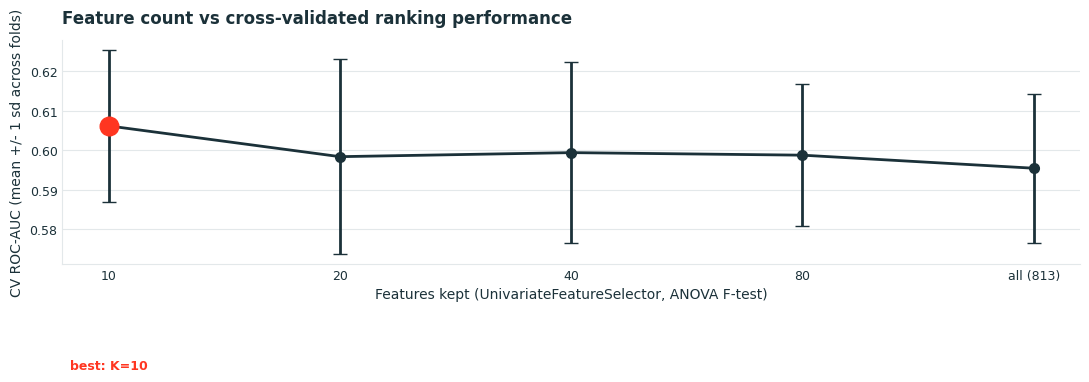

Best CV AUC at K = 10
Smallest K within 1 sd of the best: 10

Choosing K = 10 — the simplest model statistically indistinguishable from the best.


In [0]:
fig, ax = P.new_axes(P.FIGSIZE_WIDE)
x = np.arange(len(k_df))
ax.errorbar(x, k_df["cv_auc"], yerr=k_df["cv_std"], color=P.INK,
            marker="o", markersize=7, linewidth=2, capsize=5, zorder=4)

best_i = int(k_df["cv_auc"].idxmax())
ax.scatter([best_i], [k_df.loc[best_i, "cv_auc"]], s=180, color=P.ACCENT, zorder=5)
ax.annotate(f"best: K={k_df.loc[best_i, 'label']}",
            xy=(best_i, k_df.loc[best_i, "cv_auc"]),
            xytext=(best_i, k_df.loc[best_i, "cv_auc"] - k_df["cv_std"].max() * 2.5),
            ha="center", fontsize=9, color=P.ACCENT, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(k_df["label"])
P.style(ax, title="Feature count vs cross-validated ranking performance",
        xlabel="Features kept (UnivariateFeatureSelector, ANOVA F-test)",
        ylabel="CV ROC-AUC (mean +/- 1 sd across folds)")
plt.tight_layout()
plt.show()

# One-standard-error rule: smallest K statistically indistinguishable from the best.
# K=0 is the "keep everything" control, so it competes at its true width.
within_noise = k_df[k_df["cv_auc"] >= k_df["cv_auc"].max() - k_df.loc[best_i, "cv_std"]]
SELECTED_K = int(within_noise["k"].replace(0, len(pre_indices)).min())

print(f"Best CV AUC at K = {k_df.loc[best_i, 'label']}")
print(f"Smallest K within 1 sd of the best: {SELECTED_K}")
print(f"\nChoosing K = {SELECTED_K} — the simplest model statistically "
      f"indistinguishable from the best.")


**Decision rule, stated before the result was seen:** take the smallest K whose CV score is
within one standard deviation of the best. Picking the raw argmax would chase fold noise and
buy a fractional AUC point with real complexity. The one-standard-error rule is the
conventional answer to that and it is the one applied here.

---

## Stage 2a — Which model family?

The original project compared Random Forest against Gradient-Boosted Trees and stopped there.
Two tree ensembles is not a comparison, it is a preference. Four families are scored under
identical CV, at deliberately modest settings, so the question answered is *which family suits
this data* rather than *which family got tuned hardest*.

K and the family are chosen once, on the pre-departure view, and reused for the in-flight
variant. The two views differ by a single column; re-running the whole selection for each
would spend compute to re-derive the same answer.


In [ ]:
families = {
    "logistic_regression": LogisticRegression(featuresCol="selected", labelCol="label", maxIter=30),
    "decision_tree": DecisionTreeClassifier(featuresCol="selected", labelCol="label",
                                            maxDepth=8, seed=config.RANDOM_SEED),
    "random_forest": RandomForestClassifier(featuresCol="selected", labelCol="label",
                                            numTrees=40, maxDepth=8, seed=config.RANDOM_SEED),
    "gbt": GBTClassifier(featuresCol="selected", labelCol="label",
                         maxIter=25, maxDepth=5, seed=config.RANDOM_SEED),
}

family_results = []
with mlflow.start_run(run_name="stage2a_family_comparison"):
    for name, clf in families.items():
        pipeline = Pipeline(stages=[selector_stage(SELECTED_K), clf])
        _, mean_auc, std_auc = cv_score(pipeline, search_pre, SEARCH_FOLDS, "search_fold")
        family_results.append({"family": name, "cv_auc": mean_auc, "cv_std": std_auc})
        mlflow.log_metric(f"cv_auc_{name}", mean_auc)
        print(f"  {name:<22} CV ROC-AUC = {mean_auc:.4f} (+/- {std_auc:.4f})")

fam_df = pd.DataFrame(family_results).sort_values("cv_auc", ascending=False)

fig, ax = P.new_axes(P.FIGSIZE_WIDE)
ax.barh(fam_df["family"][::-1], fam_df["cv_auc"][::-1],
        xerr=fam_df["cv_std"][::-1],
        color=P.highlight_colors(fam_df["cv_auc"][::-1],
                                 lambda v: v >= fam_df["cv_auc"].max() - fam_df["cv_std"].max()),
        error_kw={"ecolor": P.INK, "capsize": 4}, zorder=3)
# FLOOR_PRE, not FLOOR_IN: this chart is the pre-departure comparison, and the
# dep_delay baseline sits at ~0.93 — plotting it here would rescale the axis and
# flatten four bars that differ by less than a standard deviation.
ax.axvline(FLOOR_PRE, color=P.INK, linestyle="--", linewidth=1.2, zorder=4)
ax.annotate("majority-class floor", xy=(FLOOR_PRE, -0.4), fontsize=8, color=P.INK)
P.style(ax, title="Model family comparison under identical blocked CV (pre-departure)",
        xlabel="CV ROC-AUC (mean +/- 1 sd)")
ax.grid(axis="y", visible=False); ax.grid(axis="x", color=P.GRID, linewidth=0.8)
plt.tight_layout(); plt.show()

display(fam_df)
gap = fam_df.iloc[0]["cv_auc"] - fam_df.iloc[1]["cv_auc"]
pooled_sd = float(np.sqrt(fam_df.iloc[0]["cv_std"] ** 2 + fam_df.iloc[1]["cv_std"] ** 2))
print(f"\nTop two families differ by {gap:.4f}; pooled fold sd is {pooled_sd:.4f}.")
print("Separated by more than fold noise." if gap > pooled_sd
      else "NOT separated by fold noise — treat the ranking as a tie and prefer the simpler model.")


That last check is the point of the section. Reporting "GBT won" without comparing the gap to
the fold-to-fold standard deviation is how projects claim a result that a reseed would
reverse. If the gap is inside the noise, the honest conclusion is a tie, and the tie goes to
the cheaper model.

---

## Stages 2b–3 as a function

Everything from here runs twice: once on the pre-departure view, once on the in-flight view.
The code paths are identical and only the input view changes, so they live in `run_variant()`
rather than being copy-pasted. The AUC gap between the two calls is the single most
interesting number this project produces — it is what the model pays for not knowing
`dep_delay`.

**Stage 2b — hyperparameter search.** A single Hyperopt trial scored by 5-fold CV on the full
CV window is five full fits. Twenty-five trials across two families is 250 fits, which will
exhaust a Free Edition compute quota. So Stage 2b searches broadly on a 25% sample with 3
folds, then Stage 2c re-scores only the surviving configurations with full 5-fold CV on all
the CV-window data. Broad and cheap, then narrow and rigorous.

**Why the objective is a CV score and not a single validation split.** Tuning against one
split selects the hyperparameters that happen to suit that split. The CV mean is the estimate
with variance information attached, and the fold standard deviation is logged so an unstable
configuration is visible rather than lucky.

**Stage 2c — confirm on the full CV window.** The Stage 2b winners were chosen on a 25%
sample with 3 folds. A configuration that suits a sample does not automatically suit the
whole. The top configurations are re-scored by `CrossValidator` with the full `CV_FOLDS`
blocked folds over all the CV-window data.

Note that Stage 2c passes **explicit `ParamMap`s**, not a `ParamGridBuilder` grid. A grid
takes the cross product — with four hyperparameters at three distinct values each that is up
to 81 configurations, not the three that survived. On a bounded quota the difference is the
whole compute budget.


In [0]:
RF_SPACE = {
    "numTrees": hp.quniform("numTrees", 20, config.RF_MAX_TREES, 10),
    "maxDepth": hp.quniform("maxDepth", 5, config.RF_MAX_DEPTH, 1),
    "minInstancesPerNode": hp.quniform("minInstancesPerNode", 10, 100, 10),
    "subsamplingRate": hp.uniform("subsamplingRate", 0.6, 1.0),
}
GBT_SPACE = {
    "maxIter": hp.quniform("maxIter", 15, config.GBT_MAX_ITER, 5),
    "maxDepth": hp.quniform("maxDepth", 3, config.GBT_MAX_DEPTH, 1),
    "stepSize": hp.loguniform("stepSize", np.log(0.03), np.log(0.3)),
    "subsamplingRate": hp.uniform("subsamplingRate", 0.6, 1.0),
}
HYPER_KEYS = {"cv_auc", "cv_std"}


def build_rf(p):
    return RandomForestClassifier(
        featuresCol="selected", labelCol="label", seed=config.RANDOM_SEED,
        numTrees=int(p["numTrees"]), maxDepth=int(p["maxDepth"]),
        minInstancesPerNode=int(p["minInstancesPerNode"]),
        subsamplingRate=float(p["subsamplingRate"]),
    )


def build_gbt(p):
    return GBTClassifier(
        featuresCol="selected", labelCol="label", seed=config.RANDOM_SEED,
        maxIter=int(p["maxIter"]), maxDepth=int(p["maxDepth"]),
        stepSize=float(p["stepSize"]), subsamplingRate=float(p["subsamplingRate"]),
    )


def search(space, builder, data, tag):
    """Hyperopt TPE where each trial's loss is a blocked-CV mean, not a single split."""
    trials = Trials()
    history = []

    def objective(params):
        pipeline = Pipeline(stages=[selector_stage(SELECTED_K), builder(params)])
        _, mean_auc, std_auc = cv_score(pipeline, data, SEARCH_FOLDS, "search_fold")
        history.append({**params, "cv_auc": mean_auc, "cv_std": std_auc})
        with mlflow.start_run(run_name=f"{tag}_trial", nested=True):
            mlflow.log_params({k: round(float(v), 4) for k, v in params.items()})
            mlflow.log_metrics({"cv_auc": mean_auc, "cv_std": std_auc})
        return {"loss": -mean_auc, "status": STATUS_OK}

    with mlflow.start_run(run_name=f"stage2b_{tag}"):
        fmin(objective, space, algo=tpe.suggest, max_evals=MAX_EVALS,
             trials=trials, show_progressbar=False,
             rstate=np.random.default_rng(config.RANDOM_SEED))
        best = sorted(history, key=lambda h: -h["cv_auc"])[:config.STAGE2_TOP_N]
        mlflow.log_metric("best_cv_auc", best[0]["cv_auc"])
    return pd.DataFrame(history), best


def confirm(builder, top_configs, data, tag):
    """Re-score exactly the surviving configs with full blocked CV on the CV window.

    Explicit ParamMaps, not ParamGridBuilder: a grid would take the cross product of
    the distinct values and re-score up to len(values)**n_params configurations.
    """
    base = builder(top_configs[0])
    param_maps = []
    for cfg in top_configs:
        candidate = builder(cfg)
        param_maps.append({
            base.getParam(k): candidate.getOrDefault(k)
            for k in cfg if k not in HYPER_KEYS
        })

    pipeline = Pipeline(stages=[selector_stage(SELECTED_K), base])
    with mlflow.start_run(run_name=f"stage2c_{tag}"):
        cv_model, mean_auc, std_auc = cv_score(
            pipeline, data, CV_FOLDS, "fold", param_grid=param_maps
        )
        mlflow.log_metrics({"confirmed_cv_auc": mean_auc, "confirmed_cv_std": std_auc})
        mlflow.log_param("configs_rescored", len(param_maps))
    print(f"{tag}: {len(param_maps)} configs re-scored on full CV window -> "
          f"CV ROC-AUC {mean_auc:.4f} (+/- {std_auc:.4f})")
    return cv_model, mean_auc, std_auc


In [0]:
def log_spark_model(model, uc_name, signature):
    """mlflow.spark.log_model across the 2.x/3.x signature change.

    MLflow 3.x renamed `artifact_path` to `name` and deprecated the old keyword;
    2.x does not accept `name`. Try the new spelling, fall back to the old.
    """
    kwargs = dict(
        spark_model=model, dfs_tmpdir=config.ARTIFACT_VOLUME,
        registered_model_name=uc_name, signature=signature,
    )
    try:
        return mlflow.spark.log_model(name="model", **kwargs)
    except TypeError:
        return mlflow.spark.log_model(artifact_path="model", **kwargs)


def model_version_of(info):
    """Registered version across MLflow versions that spell the attribute differently."""
    for attr in ("registered_model_version", "registered_model_version_number"):
        if getattr(info, attr, None) is not None:
            return getattr(info, attr)
    rm = getattr(info, "registered_model", None)
    if rm is not None and getattr(rm, "version", None) is not None:
        return rm.version
    raise AttributeError(
        f"Cannot find the registered version on {type(info).__name__}. "
        f"Available: {[a for a in dir(info) if 'version' in a.lower()]}"
    )


def register(model, sample_df, uc_name, run_name, metrics, threshold, k, extra_params=None):
    sample = sample_df.limit(5)
    signature = infer_signature(sample, model.transform(sample))
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "selected_k": k,
            "cv_folds": CV_FOLDS,
            "fold_strategy": "contiguous_time_blocks",
            "cv_window": f"<= {config.TRAIN_END_YEAR}",
            "threshold_window": str(config.THRESHOLD_YEAR),
            "test_window": str(config.TEST_YEAR),
            "decision_threshold": round(threshold, 3),
            "tuning_metric": config.TUNING_METRIC,
            "reporting_beta": config.REPORTING_BETA,
            **(extra_params or {}),
        })
        mlflow.log_metrics({k2: float(v) for k2, v in metrics.items()
                            if isinstance(v, (int, float))})
        # 07_score reads the threshold off this tag: a probability model without
        # its threshold is only half a decision system.
        mlflow.set_tag("decision_threshold", round(threshold, 4))
        info = log_spark_model(model, uc_name, signature)

    version = model_version_of(info)
    MlflowClient().set_registered_model_alias(uc_name, config.CHAMPION_ALIAS, version)
    print(f"{uc_name}  v{version}  @{config.CHAMPION_ALIAS}  threshold={threshold:.2f}")
    return info


In [ ]:
def run_variant(view_train, view_search, view_val, view_test, tag, rf_name, gbt_name):
    """Stages 2b-3 for one feature view: search, confirm, threshold, test, register."""
    print(f"\n{'=' * 70}\n{tag.upper()}\n{'=' * 70}")

    # --- Stage 2b: broad search on the sample -----------------------------------
    rf_history, rf_top = search(RF_SPACE, build_rf, view_search, f"rf_{tag}")
    print(f"RF  best sampled CV AUC: {rf_top[0]['cv_auc']:.4f}")
    gbt_history, gbt_top = search(GBT_SPACE, build_gbt, view_search, f"gbt_{tag}")
    print(f"GBT best sampled CV AUC: {gbt_top[0]['cv_auc']:.4f}")

    # Did TPE actually learn, or is this random search in a costume?
    fig, ax = P.new_axes(P.FIGSIZE_WIDE)
    for hist, name, color in [(rf_history, "Random Forest", P.INK), (gbt_history, "GBT", P.ACCENT)]:
        ax.plot(range(1, len(hist) + 1), hist["cv_auc"], marker="o", markersize=4,
                linestyle="none", color=color, alpha=0.35)
        ax.plot(range(1, len(hist) + 1), hist["cv_auc"].cummax(), color=color,
                linewidth=2.2, label=name)
    ax.legend(frameon=False, fontsize=9)
    P.style(ax, title=f"Search progress ({tag}) — running best should rise above the scatter",
            xlabel="Hyperopt trial", ylabel="CV ROC-AUC (sampled)")
    plt.tight_layout(); plt.show()

    # --- Stage 2c: confirm on the full CV window --------------------------------
    rf_cv, rf_auc, rf_sd = confirm(build_rf, rf_top, view_train, f"rf_{tag}")
    gbt_cv, gbt_auc, gbt_sd = confirm(build_gbt, gbt_top, view_train, f"gbt_{tag}")

    # Tie rule, applied rather than merely printed. Stage 2a establishes that a
    # margin inside the pooled fold standard deviation is not a result; picking the
    # argmax anyway would register a champion chosen by noise. On a tie the simpler
    # and cheaper-to-serve model wins, which here is the random forest: bagging is
    # parallel and each tree is independent, where boosting is sequential.
    margin = abs(gbt_auc - rf_auc)
    pooled = float(np.sqrt(rf_sd ** 2 + gbt_sd ** 2))
    tied = margin <= pooled

    if tied:
        winner, cv_model, cv_auc, cv_sd = "rf", rf_cv, rf_auc, rf_sd
        verdict = (f"margin {margin:.4f} <= pooled sd {pooled:.4f} -> TIE, "
                   f"taking the simpler model")
    else:
        winner, cv_model, cv_auc, cv_sd = (
            ("gbt", gbt_cv, gbt_auc, gbt_sd) if gbt_auc > rf_auc else ("rf", rf_cv, rf_auc, rf_sd)
        )
        verdict = f"margin {margin:.4f} > pooled sd {pooled:.4f} -> separated by more than noise"

    print(f"\n{tag} winner: {winner}  CV ROC-AUC {cv_auc:.4f} (+/- {cv_sd:.4f})")
    print(f"  {verdict}")

    best_model = cv_model.bestModel

    # --- Stage 3a: threshold on the 2022 window, which never entered CV ----------
    val_scored = ev.with_positive_probability(best_model.transform(view_val))
    sweep = ev.confusion_at(val_scored, config.THRESHOLD_GRID)
    chosen = ev.best_threshold(sweep, beta=config.REPORTING_BETA)
    threshold = chosen["threshold"]

    sweep_df = pd.DataFrame(sweep)
    fig, ax = P.new_axes(P.FIGSIZE_WIDE)
    ax.plot(sweep_df["threshold"], sweep_df["precision"], color=P.NEGATIVE, linewidth=2,
            label="Precision")
    ax.plot(sweep_df["threshold"], sweep_df["recall"], color=P.POSITIVE, linewidth=2,
            label="Recall")
    ax.plot(sweep_df["threshold"], sweep_df["f1"], color=P.ACCENT, linewidth=2.6, label="F1")
    ax.axvline(threshold, color=P.INK, linestyle="--", linewidth=1.4)
    ax.axvline(0.5, color=P.MUTED, linestyle=":", linewidth=1.4)
    ax.annotate(f"chosen {threshold:.2f}", xy=(threshold, 0.05), xytext=(threshold + 0.02, 0.05),
                fontsize=9, color=P.INK, fontweight="bold")
    ax.annotate("default 0.50", xy=(0.5, 0.95), xytext=(0.52, 0.95), fontsize=9, color=P.MUTED)
    ax.legend(frameon=False, fontsize=9)
    P.style(ax, title=f"Decision threshold ({tag}) selected on {config.THRESHOLD_YEAR}, not assumed",
            xlabel="P(delayed) threshold", ylabel="Score")
    plt.tight_layout(); plt.show()

    default_f1 = next(r["f1"] for r in sweep if abs(r["threshold"] - 0.5) < 1e-9)
    print(f"F1 at chosen threshold {threshold:.2f} : {chosen['f1']:.4f}")
    print(f"F1 at Spark default 0.50            : {default_f1:.4f}")
    print(f"Cost of leaving the default in place: {chosen['f1'] - default_f1:+.4f} F1")

    # --- Stage 3b: the one and only test evaluation -----------------------------
    test_pred = best_model.transform(view_test)
    final = ev.full_report(test_pred, threshold, beta=config.REPORTING_BETA)

    print(f"\nTest year {config.TEST_YEAR}, threshold {threshold:.2f}")
    for key in ("roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy", "brier"):
        print(f"  {key:<12} {final[key]:.4f}")
    print(f"\n  confusion  TP={final['tp']:,}  FP={final['fp']:,}  "
          f"FN={final['fn']:,}  TN={final['tn']:,}")
    print(f"\nCV -> test gap: {final['roc_auc'] - cv_auc:+.4f} (fold sd was {cv_sd:.4f})")

    # --- Registration -----------------------------------------------------------
    uc_name = gbt_name if winner == "gbt" else rf_name
    register(best_model, view_train, uc_name, f"champion_{winner}_{tag}",
             final, threshold, SELECTED_K, extra_params={"variant": tag})

    return {
        "tag": tag, "winner": winner, "uc_name": uc_name, "model": best_model,
        "cv_auc": cv_auc, "cv_sd": cv_sd, "threshold": threshold,
        "test": final, "test_pred": test_pred,
    }


---

## Stage 3 — Run both variants

Pre-departure first (the harder, more useful problem), then in-flight.


2026/09/09 14:46:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o60.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented


PRE_DEPARTURE


2026/09/09 14:47:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o69.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

RF  best sampled CV AUC: 0.6060


2026/09/09 14:52:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o128.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

GBT best sampled CV AUC: 0.6076


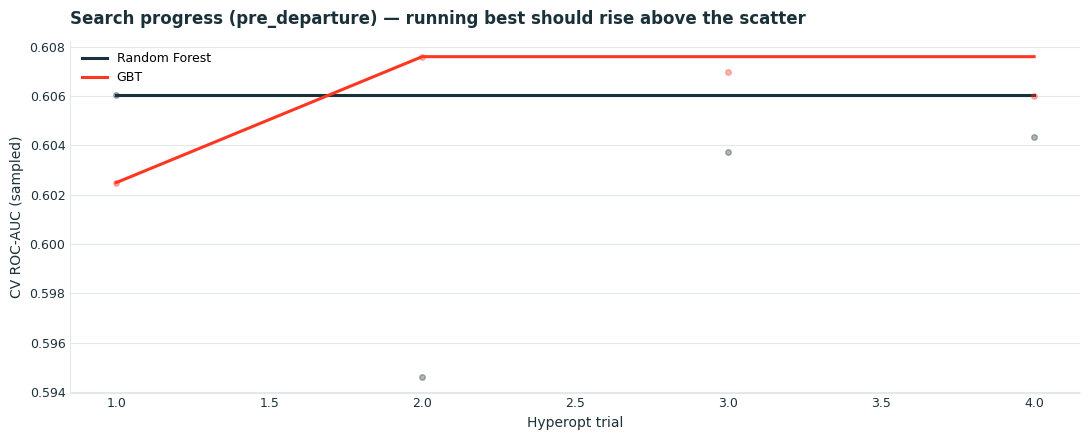

2026/09/09 14:57:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o178.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

rf_pre_departure: 3 configs re-scored on full CV window -> CV ROC-AUC 0.6006 (+/- 0.0109)
gbt_pre_departure: 3 configs re-scored on full CV window -> CV ROC-AUC 0.6035 (+/- 0.0127)

pre_departure winner: gbt  CV ROC-AUC 0.6035 (+/- 0.0127)
Margin over runner-up: 0.0029  |  pooled sd: 0.0167


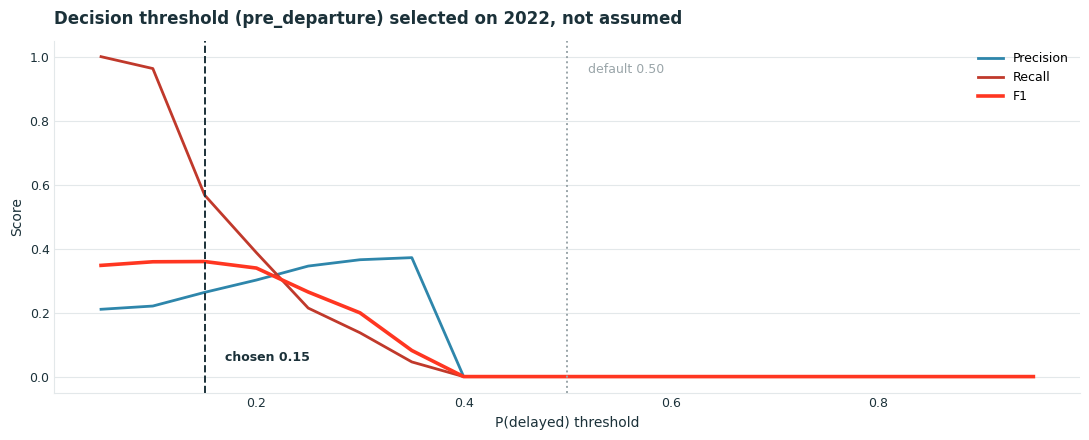

F1 at chosen threshold 0.15 : 0.3596
F1 at Spark default 0.50            : 0.0000
Cost of leaving the default in place: +0.3596 F1

Test year 2023, threshold 0.15
  roc_auc      0.6079
  pr_auc       0.3246
  f1           0.3658
  precision    0.2962
  recall       0.4781
  accuracy     0.6182
  brier        0.1759

  confusion  TP=50,034  FP=118,880  FN=54,625  TN=230,874

CV -> test gap: +0.0044 (fold sd was 0.0127)


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/09 15:14:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o202.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.

Uploading artifacts:   0%|          | 0/32 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.flights.gbt_pre_departure': https://dbc-d56728e5-4d72.cloud.databricks.com/explore/data/models/workspace/flights/gbt_pre_departure/version/2?o=991140949344710


workspace.flights.gbt_pre_departure  v2  @champion  threshold=0.15


In [0]:
pre = run_variant(train_pre, search_pre, val_pre, test_pre,
                  "pre_departure", config.MODEL_RF_PRE, config.MODEL_GBT_PRE)


2026/09/09 15:15:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o228.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente


IN_FLIGHT


2026/09/09 15:16:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o237.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

RF  best sampled CV AUC: 0.8866


2026/09/09 15:21:19 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o296.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

GBT best sampled CV AUC: 0.9206


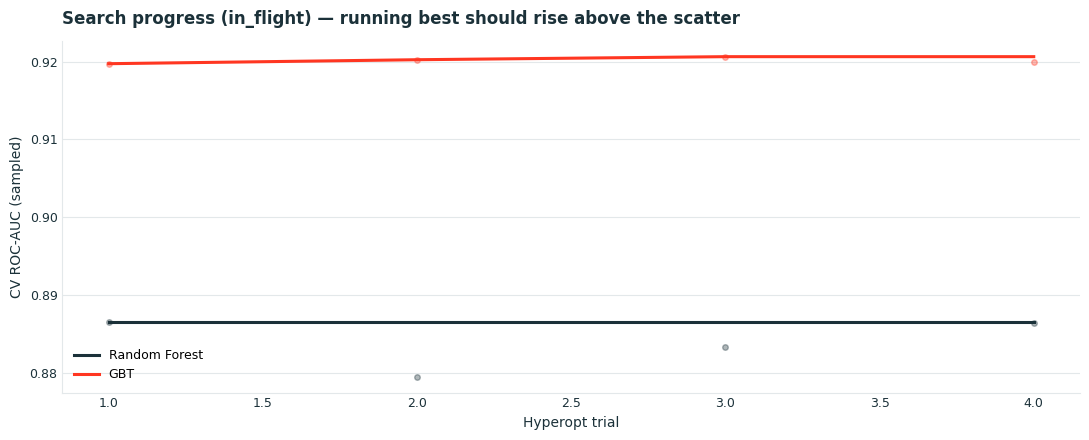

2026/09/09 15:26:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o346.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

rf_in_flight: 3 configs re-scored on full CV window -> CV ROC-AUC 0.7512 (+/- 0.1615)
gbt_in_flight: 3 configs re-scored on full CV window -> CV ROC-AUC 0.7573 (+/- 0.1665)

in_flight winner: gbt  CV ROC-AUC 0.7573 (+/- 0.1665)
Margin over runner-up: 0.0061  |  pooled sd: 0.2319


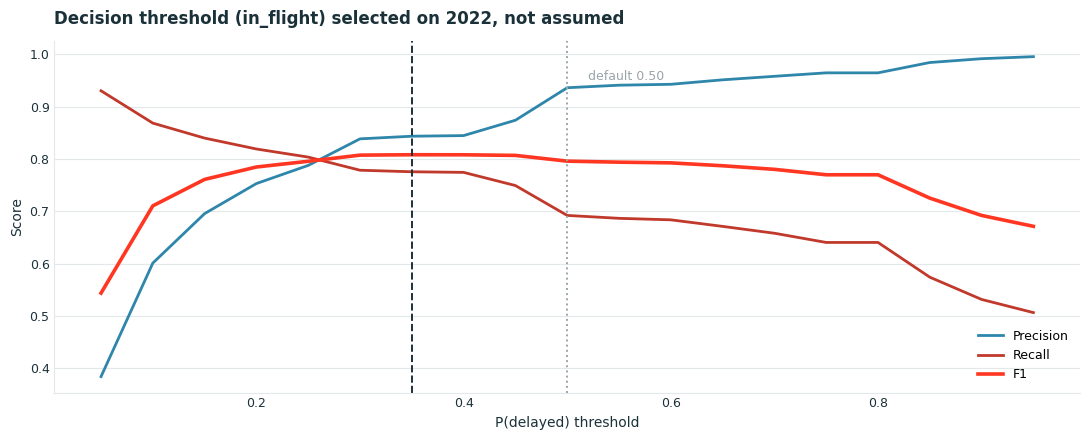

F1 at chosen threshold 0.35 : 0.8079
F1 at Spark default 0.50            : 0.7956
Cost of leaving the default in place: +0.0123 F1

Test year 2023, threshold 0.35
  roc_auc      0.9275
  pr_auc       0.8864
  f1           0.8128
  precision    0.8567
  recall       0.7732
  accuracy     0.9180
  brier        0.0635

  confusion  TP=80,922  FP=13,538  FN=23,737  TN=336,216

CV -> test gap: +0.1702 (fold sd was 0.1665)


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/09 15:43:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o370.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.

Uploading artifacts:   0%|          | 0/32 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.flights.gbt_in_flight': https://dbc-d56728e5-4d72.cloud.databricks.com/explore/data/models/workspace/flights/gbt_in_flight/version/2?o=991140949344710


workspace.flights.gbt_in_flight  v2  @champion  threshold=0.35


In [0]:
inflight = run_variant(train_in, search_in, val_in, test_in,
                       "in_flight", config.MODEL_RF_IN, config.MODEL_GBT_IN)


## The price of predicting before pushback

This is the number the project exists to produce. The in-flight model knows the actual
departure delay; the pre-departure model has to predict without it, which is the only
version of the problem that is useful before a flight leaves. The gap is what that
knowledge is worth.


In [ ]:
comparison = pd.DataFrame([
    {"variant": "majority class (baseline)", "cv_auc": None, "test_auc": 0.5,
     "test_pr_auc": None, "test_f1": FLOOR_PRE_F1, "threshold": None, "winner": "-"},
    {"variant": "pre-departure (no dep_delay)", "cv_auc": pre["cv_auc"],
     "test_auc": pre["test"]["roc_auc"], "test_pr_auc": pre["test"]["pr_auc"],
     "test_f1": pre["test"]["f1"], "threshold": pre["threshold"], "winner": pre["winner"]},
    {"variant": "dep_delay alone (baseline)", "cv_auc": None, "test_auc": FLOOR_IN,
     "test_pr_auc": None, "test_f1": FLOOR_IN_F1, "threshold": 0.5, "winner": "-"},
    {"variant": "in-flight (with dep_delay)", "cv_auc": inflight["cv_auc"],
     "test_auc": inflight["test"]["roc_auc"], "test_pr_auc": inflight["test"]["pr_auc"],
     "test_f1": inflight["test"]["f1"], "threshold": inflight["threshold"],
     "winner": inflight["winner"]},
])
display(comparison)

auc_gap = inflight["test"]["roc_auc"] - pre["test"]["roc_auc"]
f1_gap = inflight["test"]["f1"] - pre["test"]["f1"]
lift_over_one_feature = inflight["test"]["roc_auc"] - FLOOR_IN

fig, ax = P.new_axes(P.FIGSIZE_WIDE)
labels = ["majority\nclass", "pre-departure", "dep_delay\nalone", "in-flight"]
aucs = [0.5, pre["test"]["roc_auc"], FLOOR_IN, inflight["test"]["roc_auc"]]
colors = [P.MUTED, P.ACCENT, P.MUTED, P.ACCENT]
bars = ax.bar(labels, aucs, color=colors, zorder=3, width=0.55)
P.annotate_bars(ax, bars, [f"{v:.4f}" for v in aucs])
ax.set_ylim(0.45, 1.0)
P.style(ax, title="Test ROC-AUC — each model against the baseline it should be judged on",
        ylabel=f"Test ROC-AUC ({config.TEST_YEAR})")
plt.tight_layout(); plt.show()

print(f"Test ROC-AUC gap (in-flight - pre-departure): {auc_gap:+.4f}")
print(f"Test F1 gap:                                  {f1_gap:+.4f}")
print("\nThat gap is the measurable price of predicting before pushback.")
print("\n" + "=" * 70)
print("The finding that matters more, and the one worth leading with:")
print("=" * 70)
print(f"  in-flight model      ROC-AUC {inflight['test']['roc_auc']:.4f}")
print(f"  dep_delay alone      ROC-AUC {FLOOR_IN:.4f}")
print(f"  lift from the other {len(pre_indices)} features: {lift_over_one_feature:+.4f}")
print()
if lift_over_one_feature < 0.01:
    print("  The in-flight model is a one-feature model wearing 800 features. Once")
    print("  departure delay is known, arrival delay is nearly determined by it, and")
    print("  the engineered features add almost nothing on top.")
    print()
    print("  This is why the pre-departure variant is the one worth building: it is")
    print("  the only version of the problem where the features have to do the work,")
    print("  and it is the only version that is useful before a flight leaves the gate.")
else:
    print("  The engineered features add measurable lift over departure delay alone.")


## Calibration — does 70% mean 70%?

The app surfaces a probability to a user. Ranking correctly is not enough: if the model says
70% and those flights are delayed 45% of the time, the number displayed is misleading even
though ROC-AUC looks fine. Tree ensembles are known to be poorly calibrated — bagging pushes
probabilities toward the centre, boosting pushes them toward the extremes.


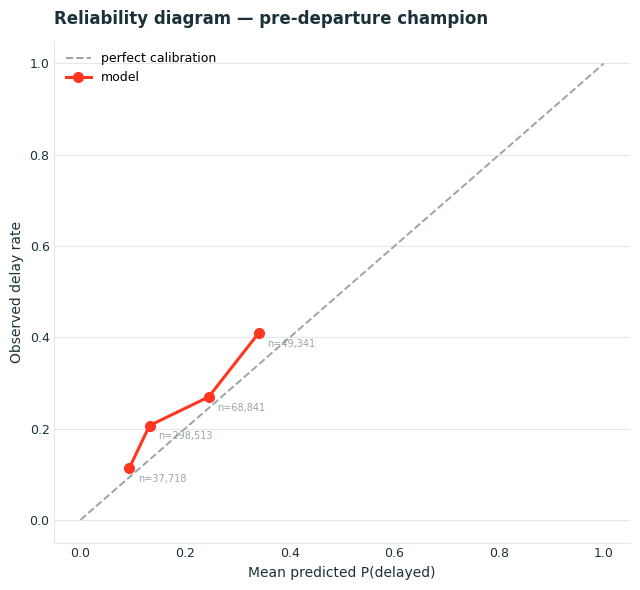

Brier score          : 0.1759
Largest bin deviation: 0.075

Above the diagonal = under-confident; below = over-confident.
If deviation exceeds ~0.05, fit isotonic regression on the 2022 probabilities
and apply it before the app displays a percentage.


In [0]:
test_scored = ev.with_positive_probability(pre["test_pred"])
bins = ev.calibration_bins(test_scored, n_bins=10)

fig, ax = P.new_axes((6.5, 6))
ax.plot([0, 1], [0, 1], color=P.MUTED, linestyle="--", linewidth=1.4,
        label="perfect calibration")
ax.plot(bins["mean_predicted"], bins["observed_rate"], color=P.ACCENT,
        marker="o", markersize=7, linewidth=2.2, label="model")
for _, r in bins.iterrows():
    ax.annotate(f"n={int(r['n']):,}", (r["mean_predicted"], r["observed_rate"]),
                textcoords="offset points", xytext=(6, -10), fontsize=7, color=P.MUTED)
ax.legend(frameon=False, fontsize=9)
P.style(ax, title="Reliability diagram — pre-departure champion",
        xlabel="Mean predicted P(delayed)", ylabel="Observed delay rate")
plt.tight_layout(); plt.show()

max_gap = float((bins["observed_rate"] - bins["mean_predicted"]).abs().max())
print(f"Brier score          : {pre['test']['brier']:.4f}")
print(f"Largest bin deviation: {max_gap:.3f}")
print("\nAbove the diagonal = under-confident; below = over-confident.")
print("If deviation exceeds ~0.05, fit isotonic regression on the 2022 probabilities")
print("and apply it before the app displays a percentage.")


## Feature importance — cross-checking the univariate filter

Stage 1 selected features with a univariate ANOVA filter, which cannot see interactions. The
fitted ensemble's `featureImportances` is an embedded method that can. Comparing the two is a
check on Stage 1: broad agreement means the filter did not discard something the trees rely on.


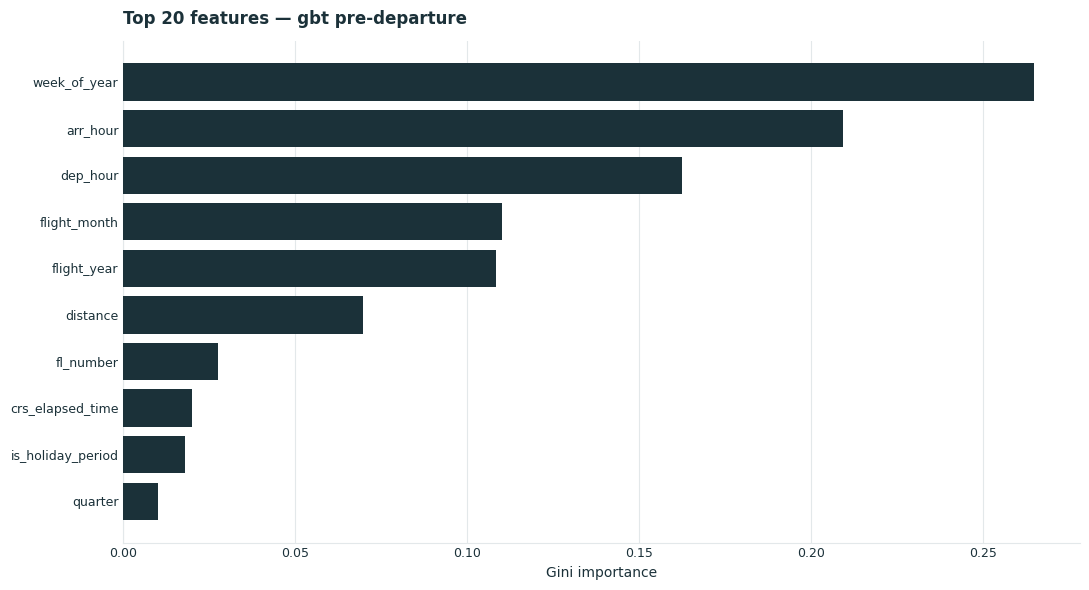

Top 5 carry 85.5% of total importance.

Caveat worth stating in the README: Gini importance is biased toward
high-cardinality features, which inflates the one-hot airport columns.
Permutation importance on the test set is the unbiased alternative if
compute allows.


In [0]:
best_model = pre["model"]
selector_model = best_model.stages[0]
classifier = best_model.stages[-1]

name_by_index = {v: k for k, v in index_by_name.items()}
pre_names = [name_by_index[i] for i in pre_indices]
kept = (selector_model.selectedFeatures if hasattr(selector_model, "selectedFeatures")
        else list(range(len(pre_names))))
kept_names = [pre_names[i] for i in kept]

importances = classifier.featureImportances.toArray()
imp = (pd.DataFrame({"feature": kept_names[:len(importances)], "importance": importances})
       .sort_values("importance", ascending=False).head(20))

fig, ax = P.new_axes((11, 6))
ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=P.INK, zorder=3)
P.style(ax, title=f"Top 20 features — {pre['winner']} pre-departure", xlabel="Gini importance")
ax.grid(axis="y", visible=False); ax.grid(axis="x", color=P.GRID, linewidth=0.8)
plt.tight_layout(); plt.show()

print(f"Top 5 carry {imp['importance'].head(5).sum():.1%} of total importance.")
print("\nCaveat worth stating in the README: Gini importance is biased toward")
print("high-cardinality features, which inflates the one-hot airport columns.")
print("Permutation importance on the test set is the unbiased alternative if")
print("compute allows.")


## Error analysis — where does it fail?

A single test AUC says nothing about *which* flights the model gets wrong. Slicing the errors
is what turns a metric into a finding, and it is the section that produces the honest
limitations paragraph.


In [0]:
errors = (
    test_scored
    .withColumn("predicted", (col(ev.POSITIVE_PROBABILITY) >= F.lit(pre["threshold"])).cast("int"))
    .withColumn("correct", (col("predicted") == col("label").cast("int")).cast("int"))
)

by_actual = (
    errors.groupBy("label")
    .agg(F.avg("correct").alias("accuracy"), F.count("*").alias("n"))
    .orderBy("label").toPandas()
)
display(by_actual)

final = pre["test"]
print("Accuracy on the delayed class is the number that matters — it is recall by")
print("another name, and it is where an imbalanced model quietly fails.")
print(f"\nFalse negatives: {final['fn']:,} delayed flights the model called on time.")
print(f"False positives: {final['fp']:,} on-time flights it flagged.")
print(f"FN:FP ratio {final['fn'] / max(final['fp'], 1):.2f} — if a missed delay is")
print("more costly than a false alarm, raise REPORTING_BETA and re-select the threshold.")


label,accuracy,n
0.0,0.6601039587824585,349754
1.0,0.47806686477034943,104659


Accuracy on the delayed class is the number that matters — it is recall by
another name, and it is where an imbalanced model quietly fails.

False negatives: 54,625 delayed flights the model called on time.
False positives: 118,880 on-time flights it flagged.
FN:FP ratio 0.46 — if a missed delay is
more costly than a false alarm, raise REPORTING_BETA and re-select the threshold.


## Exit test — load from Unity Catalog by alias

This is the cell that proves the original project's blocker is dead: the champion is
re-opened by its 3-level Unity Catalog name and `@champion` alias, not by run ID, and it
scores rows. Screenshot it.


In [0]:
for result in (pre, inflight):
    reloaded = mlflow.spark.load_model(
        f"models:/{result['uc_name']}@{config.CHAMPION_ALIAS}",
        dfs_tmpdir=config.ARTIFACT_VOLUME,
    )
    view = test_pre if result["tag"] == "pre_departure" else test_in
    preview = ev.with_positive_probability(reloaded.transform(view.limit(10)))
    print(f"\n{result['uc_name']} @{config.CHAMPION_ALIAS}  "
          f"(threshold {result['threshold']:.2f})")
    display(preview.select("label", ev.POSITIVE_PROBABILITY, "prediction"))

print("\nBoth champions load by alias and score. Screenshot this cell.")



workspace.flights.gbt_pre_departure @champion  (threshold 0.15)


label,p1,prediction
1.0,0.1329664647693014,0.0
0.0,0.1260613411471434,0.0
0.0,0.11028045832602829,0.0
1.0,0.13206106492467995,0.0
0.0,0.10531828604371696,0.0
0.0,0.09626682325301328,0.0
0.0,0.2409683333659477,0.0
0.0,0.17180319379328468,0.0
0.0,0.12488031315330206,0.0
0.0,0.14941832512718123,0.0



workspace.flights.gbt_in_flight @champion  (threshold 0.35)


label,p1,prediction
1.0,0.06136148842047551,0.0
0.0,0.03852843874046408,0.0
0.0,0.0503296042164435,0.0
1.0,0.9752392403680573,1.0
0.0,0.03883934326021221,0.0
0.0,0.05975733925313553,0.0
0.0,0.03852843874046408,0.0
0.0,0.24102333950599686,0.0
0.0,0.11681941885000291,0.0
0.0,0.04355079610585977,0.0



Both champions load by alias and score. Screenshot this cell.


## What this notebook decided

| Decision | Method | Defence |
|---|---|---|
| Train/test split | Temporal holdout: CV ≤2021, threshold 2022, test 2023 | Delay cascades within a day (02_eda §3); random split leaks |
| Threshold window | 2022 carved out *before* CV, never trained on | `CrossValidator.fit()` refits `bestModel` on its whole input, so any CV fold is in-sample by the time a champion exists |
| CV folds | `CrossValidator(foldCol=...)`, contiguous quarters, one column per granularity | Random folds reintroduce the leak the outer split removed; `foldCol` values must be exactly `[0, numFolds)` |
| Feature count K | Swept over candidates, one-standard-error rule | Argmax chases fold noise; simplest model within 1 sd is the defensible pick |
| Selection method | `UnivariateFeatureSelector` as a Pipeline stage | Refit per fold — selecting before the split inflates every downstream score |
| `dep_delay` index | Resolved from vector metadata, else the saved pipeline; asserted | A magic index silently leaks the target when column order changes |
| Baselines | Two floors: majority class for pre-departure, `dep_delay` alone for in-flight | Holding the pre-departure model to a `dep_delay` floor judges it against information it is defined not to have |
| Model family | Four families, identical CV, gap vs pooled fold sd | A win inside fold noise is a tie |
| Champion on a tie | Margin ≤ pooled fold sd → take the random forest | Registering the argmax of a margin under one sd registers a champion chosen by noise |
| Hyperparameters | TPE on sample with CV objective, confirmed by explicit ParamMaps | Single-split tuning selects for the split; a grid would re-score the cross product, not the survivors |
| Decision threshold | F-beta-optimal on 2022, applied unchanged to 2023 | 0.5 is not optimal under imbalance and costs measurable F1 |
| Both variants | Stages 2b–3 run through one function for pre-departure and in-flight | The AUC gap is the price of predicting before pushback |
| Reported metric | F1 + PR-AUC at a stated threshold; ROC-AUC for tuning | Accuracy is beaten by the do-nothing baseline (02_eda §2) |
| Probability quality | Reliability diagram + Brier | The app shows a percentage to a user; it has to mean something |
